This notebook is trying to see if rev KL training can help -> I doubt it if we have an issue with entropy already!

For splines it borrows from
https://github.com/VincentStimper/normalizing-flows/blob/master/examples/neural_spline_flow.ipynb 



In [13]:
# Import required packages
import torch
import numpy as np
import normflows as nf\

from matplotlib import pyplot as plt

from tqdm import tqdm

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS, get_participation_ratio
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

import copy 

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

Saved trained models

In [62]:
mode_labels = [0, 1]
flows_dic = [load_pickle_file('models/is{:d}_flow_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]
mlps_dic = [load_pickle_file('models/is{:d}_mlp_dic_training.pkl'.format(mode_label)) for mode_label in mode_labels]

# trained'
flows = get_models(flows_dic)
mlps = get_models(mlps_dic) 

In [63]:
# kb in ev/K
T = 300
kb = 8.617333262145e-5
beta = 1 / (kb * T)

The spline option

In [4]:
# Define flows
# number of?
K = 16
torch.manual_seed(0)

latent_size = 12
hidden_units = 128
hidden_layers = 2
flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

# Set prior and q0
q0 = nf.distributions.DiagGaussian(12, trainable=False)
    
# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
nfm = nfm.to(device)

# Loading MD data

In [4]:
coord_mapping = Coordinates_mapping() 


mode_labels = [0, 1]
dataset_label = 'md_train'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']

zmats = []
xs = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 14],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 12])
    x = join_data(x, energies, zmat[:, 13], logdetjac,)
    
    zmats.append(zmat)
    xs.append(x)

xs = torch.cat(xs)
x_mds = xs

/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/Users/marylou/opt/anaconda3/envs/envflodft/lib/python3.9/site-packages/chemcoord/_generic_classes/generic_co

In [6]:
mode_labels = [0, 1]
dataset_label = 'md_test'
# dataset_labels = ['md_train', 'md_test', 'flow_train', 'flow_test']

zmats = []
xs_test = []
for mode_label in mode_labels:
    file='datasets/is{:d}_{:s}.csv'.format(mode_label, dataset_label)
    zmat = load_csv_file(file)
    
    x, logdetjac, energies = coord_mapping.get_real_centered_from_internal(zmat[:, :12], 
                                                                        zmat[:, 14],  
                                                                        isomer=mode_label,
                                                                        energies=zmat[:, 12])
    x = join_data(x, energies, zmat[:, 13], logdetjac,)
    
    zmats.append(zmat)
    xs_test.append(x)

xs_test = torch.cat(xs_test)
x_test_mds = xs_test

In [7]:
x_mds.shape
x_test_mds.shape

torch.Size([2002, 15])

In [8]:
def get_ratio_acc(model, init, n_chains, mlp_model, T=300):
    
    if isinstance(model, RealNVP_MLP):
        sample_fn = lambda n: model.sample(n)
        log_prob_fn = lambda x: - model.nll(x)
    else:
        sample_fn = lambda n: model.sample(n)[0]
        log_prob_fn = lambda x: model.log_prob(x)
    
    assert init.shape[0] == n_chains

    beta = 1 / (kb * T)

    x_init = init[:, :12]
    u_init = init[:, 12]
    isomer_init = init[:, 13]

    x_new= sample_fn(n_chains)
    isomer_new = isomer_init

    x_new = x_new.clone().detach().float()
    isomer_new = isomer_new.clone().detach().float()

    nll_x = - log_prob_fn(x_new)
    nll_x_init = - log_prob_fn(x_init)

    u_new = torch.zeros((n_chains, 1))
    u_new = mlp_model(x_new)
    u_new = u_new.squeeze().float()

    ratio = -beta * u_new + nll_x
    ratio += beta * u_init - nll_x_init
    ratio = torch.exp(ratio)

    return torch.minimum(torch.ones_like(ratio), ratio).detach().cpu().numpy()

# Training Flows

In [37]:
def rev_kld(model, mlp, batch_size, beta=beta):
    
    if isinstance(model, RealNVP_MLP):
        sample_fn = lambda n: model.sample(n)
        log_prob_fn = lambda x: - model.nll(x)
    else:
        sample_fn = lambda n: model.sample(n)[0]
        log_prob_fn = lambda x: model.log_prob(x)
    
    x = sample_fn(batch_size)
    
    nll_x = - log_prob_fn(x)
    u_x = mlp(x)
    u_x = u_x.squeeze().float()
    
    return torch.mean(nll_x + beta * u_x) #.detach().cpu()

In [43]:
def train_flow(model, mlp, x_test, max_iter=10000, report_split=10, batch_size=1000, x_train=None):
    losses = []
    test_losses = []
    participation_ratios = [] 
    models = [copy.deepcopy(model)]

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    for it in tqdm(range(max_iter)):
        optimizer.zero_grad()

        # Compute loss
        loss = rev_kld(model, mlp, batch_size=batch_size) 
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            optimizer.step()
        
        # Log loss
        losses.append(loss.to('cpu').data.numpy())

        if (it + 1) % int(max_iter / report_split) == 0:
            model.eval()
            # test_losses.append(model.forward_kld(x_test[:,:12]).to('cpu').data.numpy())
            participation_ratios.append(get_participation_ratio(model, mlp, batch_size).item())
            # models.append(copy.deepcopy(model))
            model.train()
    
    return losses, test_losses, participation_ratios #, models
        

In [73]:
mode_label = 0
model = flows_dic[mode_label]['models'][-1]

# Train model
max_iter = 0 #00
batch_size = 1000
report_split = 1 #25

x = (x_mds[x_mds[:, 13] == mode_label]).float()
x_train = x[:3750]
x_train = x_train[:, :12].detach()
x_test = x[3750:]

mlp = mlps[mode_label]

target_log_prob_fn = lambda x: - beta * mlp(x)

losses, test_losses, participation_ratios = train_flow(model, mlps[mode_label], x_test, max_iter=max_iter, report_split=report_split, batch_size=1000, x_train=x_train)

0it [00:00, ?it/s]


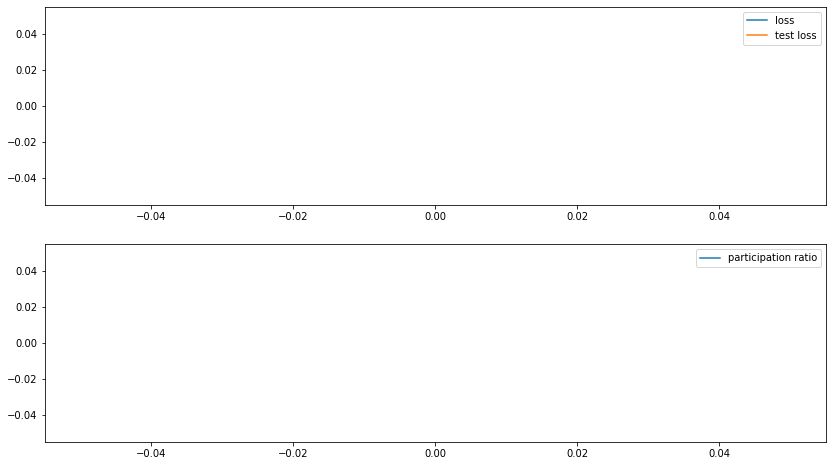

In [74]:
plt.figure(figsize=(14, 8))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
plt.sca(axes[0])
plt.plot(losses, label='loss')
plt.plot(np.arange(len(test_losses)) * report_split, test_losses, label='test loss')
plt.legend()

plt.sca(axes[1])
plt.plot(participation_ratios, label='participation ratio')
plt.legend()
plt.show()

## Equilibrating the MCMCs to see if something happened

In [75]:
def run_metropolis_rqs(model,
    init,
    n_chains,
    n_steps,
    mlp_model,
    T=300,
    with_tqdm=False,
):
    assert init.shape[0] == n_chains

    if isinstance(model, RealNVP_MLP):
        sample_fn = lambda n: model.sample(n)
        log_prob_fn = lambda x: - model.nll(x)
    else:
        sample_fn = lambda n: model.sample(n)[0]
        log_prob_fn = lambda x: model.log_prob(x)

    x_init = init[:, :12]
    u_init = init[:, 12]
    isomer_init = init[:, 13]

    beta = 1 / (kb * T)

    xs = []
    us = []
    accs = []
    ratios = []
    nlls = []

    pbar = tqdm(range(n_steps))

    for dt in pbar:
        x_new = sample_fn(n_chains)
        isomer_new = isomer_init

        x_new = x_new.clone().detach().float()
        isomer_new = isomer_new.clone().detach().float()

        nll_x = - log_prob_fn(x_new)
        nll_x_init = - log_prob_fn(x_init)
       
        u_new = mlp_model(x_new).squeeze().float()

        ratio = -beta * u_new + nll_x
        ratio += beta * u_init - nll_x_init
        ratio = torch.exp(ratio)
        u = torch.rand_like(ratio)
        ratio = torch.min(ratio, torch.ones_like(ratio))

        acc = u < torch.min(ratio, torch.ones_like(ratio))

        x_new[~acc] = x_init[~acc]
        u_new[~acc] = u_init[~acc]

        isomer_new = isomer_init

        xs.append(x_new.float().clone())
        us.append(u_new.float().clone())
        accs.append(acc.float().clone())
        nlls.append(nll_x.float().clone())
        ratios.append(ratio.mean().float().clone())

        x_init = x_new.clone().detach()
        u_init = u_new.clone().detach()
        isomer_init = isomer_new.clone().detach()

        if with_tqdm:
            pbar.set_description(f'acc: {ratio.mean().item() :.2f}')

    return torch.stack(xs), torch.stack(us), torch.stack(accs), torch.stack(nlls), torch.stack(ratios)

In [76]:
mode_label = 0
n_steps = 100
n_chains = 100

mcmc_runs = []
# for m,model in enumerate(models[::2]):
x_init = x_test[:n_chains]
mcmc_run = run_metropolis_rqs(model, x_init, x_init.shape[0], n_steps, mlps[mode_label], T=300, with_tqdm=True)
mcmc_runs.append(mcmc_run)
    


acc: 0.00: 100%|██████████| 100/100 [00:13<00:00,  7.29it/s]


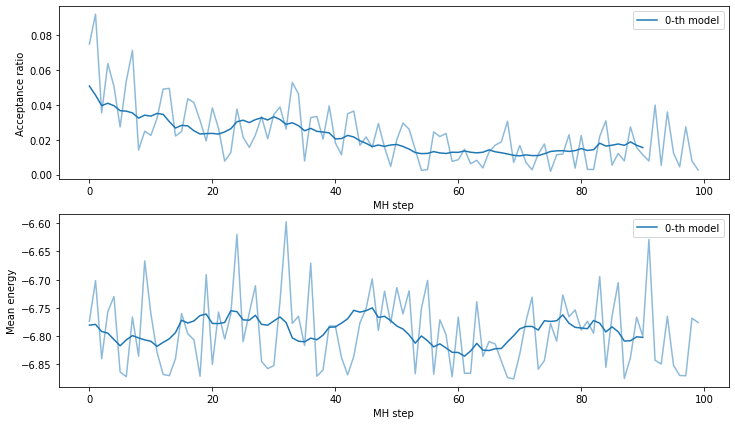

In [77]:
plt.figure(figsize=(12,7))
axes = [plt.subplot(2, 1, i + 1) for i in range(2)]
for m,mcmc_run in enumerate(mcmc_runs):
    
    xs, us, accs, nlls, ratios = mcmc_run
    plt.sca(axes[0])
    _ = plt.plot(ratios.detach().numpy(), alpha=0.5)
    plt.plot(moving_average(ratios.detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2 * m))
    plt.xlabel('MH step')
    plt.ylabel('Acceptance ratio')
    plt.legend(ncol=2)

    plt.sca(axes[1]) 
    _ = plt.plot(us.mean(0).detach().numpy(), alpha=0.5)
    plt.plot(moving_average(us.mean(0).detach().numpy(), 10), c=_[0].get_color(), label='{:d}-th model'.format(2* m))
    plt.xlabel('MH step')
    plt.ylabel('Mean energy')
    plt.legend(ncol=2)


# Looking the disctributions of flow and mlp energies 

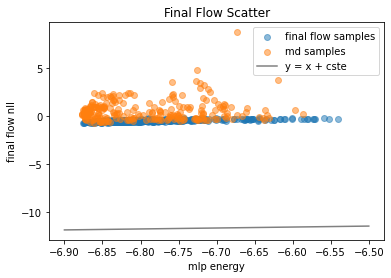

In [78]:
xs_flow = model.sample(1000)

plt.title('Final Flow Scatter')
plt.scatter(mlps[mode_label](xs_flow).detach().numpy(), model.nll(xs_flow).detach().numpy()/beta, alpha=0.5, label='final flow samples')
plt.scatter(mlps[mode_label](x_test[:,:12]).detach().numpy(), model.nll(x_test[:,:12]).detach().numpy()/beta, alpha=0.5, label='md samples')
plt.plot(np.arange(-6.9, -6.5, 0.01), np.arange(-6.9, -6.5, 0.01) - 5 , c='grey', label='y = x + cste')
plt.ylabel('final flow nll')
plt.xlabel('mlp energy')
plt.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


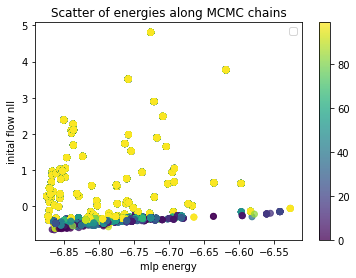

In [79]:
plt.title('Scatter of energies along MCMC chains')
steps = 100
for chain in range(100):
    # plt.plot(mlps[mode_label](xs[chain][:steps]).detach().numpy(), - final_flow.log_prob(xs[chain][:steps]).detach().numpy()/beta, '-', alpha=0.5, label='inital flow samples')
    plt.scatter(mlps[mode_label](xs[:steps, chain, :]).detach().numpy(),model.nll(xs[:steps, chain, :]).detach().numpy()/beta,  c=np.arange(steps), cmap='viridis', alpha=0.75)
plt.colorbar()
# plt.plot(mlps[mode_label](x_test[:,:12]).detach().numpy(), - init_flow.log_prob(x_test[:,:12]).detach().numpy(), alpha=0.5, label='md samples')
plt.ylabel('inital flow nll')
plt.xlabel('mlp energy')
plt.legend()